# Car data assessment 

### Objective
The purpose of this notebook is to build an End-to-End Machine Learning model using Linear Regression to estimate the realistic selling price of used cars. We accomplish this by mapping historical records containing categorical variables (e.g., fuel type, transmission) and numerical variables (e.g., mileage, year, present price). By applying exploratory data analysis, data pre-processing, and extensive feature engineering (polynomial terms and interaction features), we optimize the base model performance to provide accurate real-world car valuations based on given specifications.

### Features Description:
* **Car_Name** : Name of the cars
* **Year** : Year of the car when it was bought
* **Selling_Price** : Price at which the car is being sold
* **Kms_Driven** : Number of Kilometres the car is driven
* **Fuel_Type** : Fuel type of car (petrol / diesel / CNG / LPG / electric)
* **Seller_Type** : Tells if a Seller is Individual or a Dealer
* **Transmission** : Gear transmission of the car (Automatic/Manual)
* **Owner** : Number of previous owners of the car.

## 1. Environment Setup & Data Loading
Importing necessary libraries and reading the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold,cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
from types import SimpleNamespace
from sklearn.pipeline import Pipeline



In [2]:
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv(r'src/cardata.csv')
data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [4]:
df = pd.DataFrame(data)
print(df.shape)
df.info()

(301, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.isna().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

As we can see from the output above, there are **no missing values** in the dataset, so we do not need to perform any missing value imputation.

## 2. Data Preprocessing & Feature Engineering
### Calculating the age of cars explicitly, encoding categorical variables, and checking basic statistics:

### Custom Summary Statistics
To gain a clearer understanding of our dataset's structure, we will define a custom helper function. This function generates a comprehensive summary table detailing each feature's total counts, the number of unique entries, and any missing values, allowing us to quickly assess overall data quality.

In [6]:
def describe(df):

    variable = []
    unique = []
    count = []
    missing_values = []
    

    for col in df.columns:
        variable.append(col)
        count.append(df[col].count())
        unique.append(len(df[col].unique()))
        missing_values.append(df[col].isna().sum())

    return(pd.DataFrame({
        'variables' : variable,
        'count' : count,
        'unique' : unique,
        'missing_values': missing_values
    }
    ))



In [7]:
describe(df)

,variables,count,unique,missing_values
0,Car_Name,301,98,0
1,Year,301,16,0
2,Selling_Price,301,156,0
3,Present_Price,301,147,0
4,Kms_Driven,301,206,0
5,Fuel_Type,301,3,0
6,Seller_Type,301,2,0
7,Transmission,301,2,0
8,Owner,301,3,0


### Finding the Newest Car and Calculating Age
Machine learning models often perform better with relative metrics like "Age" rather than raw calendar years. Here, we find the newest car in the dataset (which happens to be from 2018). We will use this year as our baseline to calculate the relative "Age" of every other car by subtracting its purchase year from this newest year (2018). This transforms `Year` into a continuous variable representing depreciation over time.

In [8]:
print(np.max(df.Year))

2018


In [9]:
last_year = df[df['Year'] == 2018]
last_year


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0


In [10]:
df['Year'] = (2018 - df['Year'])
df.rename(columns={'Year':'Age'},inplace=True)
df.Age

0      4
1      5
2      1
3      7
4      4
      ..
296    2
297    3
298    9
299    1
300    2
Name: Age, Length: 301, dtype: int64

### Feature Encoding
Since machine learning algorithms require numerical input, we must transform our categorical variables (`Fuel_Type`, `Seller_Type`, `Transmission`) into a numerical format. We achieve this using One-Hot Encoding via pandas' `get_dummies` function. Additionally, we use the `drop_first=True` parameter to drop the first dummy variable for each category. This strategy prevents perfect multicollinearity—commonly known as the dummy variable trap—which can negatively impact the stability and performance of linear regression models.

In [11]:
df_nummeric = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True, dtype=int)
df_nummeric.head()

,Car_Name,Age,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,ritz,4,3.35,5.59,27000,0,0,1,0,1
1,sx4,5,4.75,9.54,43000,0,1,0,0,1
2,ciaz,1,7.25,9.85,6900,0,0,1,0,1
3,wagon r,7,2.85,4.15,5200,0,0,1,0,1
4,swift,4,4.60,6.87,42450,0,1,0,0,1


## 3. Exploratory Data Analysis (EDA)
#### Visualizing relationships between features and the target variable (`Selling_Price`):

### Correlation Analysis
To determine the strength and direction of linear relationships between our variables, we compute the Pearson correlation coefficients. Values approaching `1` or `-1` indicate strong positive or negative correlations, respectively. Assessing this matrix helps us identify highly predictive features—such as `Present_Price`, which exhibits a strong positive correlation with `Selling_Price`—while also allowing us to monitor for potential multicollinearity among independent variables.

In [12]:
df_corr = df_nummeric.drop('Car_Name',axis=1)
df_corr.corr()

,Age,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Age,1.000000,-0.236141,0.047584,0.524342,0.182104,-0.064315,0.059959,0.039896,-0.000394
Selling_Price,-0.236141,1.000000,0.878983,0.029187,-0.088344,0.552339,-0.540571,-0.550724,-0.367128
Present_Price,0.047584,0.878983,1.000000,0.203647,0.008057,0.473306,-0.465244,-0.512030,-0.348715
Kms_Driven,0.524342,0.029187,0.203647,1.000000,0.089216,0.172515,-0.172874,-0.101419,-0.162510
Owner,0.182104,-0.088344,0.008057,0.089216,1.000000,-0.053469,0.055687,0.124269,-0.050316
Fuel_Type_Diesel,-0.064315,0.552339,0.473306,0.172515,-0.053469,1.000000,-0.979648,-0.350467,-0.098643
Fuel_Type_Petrol,0.059959,-0.540571,-0.465244,-0.172874,0.055687,-0.979648,1.000000,0.358321,0.091013
Seller_Type_Individual,0.039896,-0.550724,-0.512030,-0.101419,0.124269,-0.350467,0.358321,1.000000,0.063240
Transmission_Manual,-0.000394,-0.367128,-0.348715,-0.162510,-0.050316,-0.098643,0.091013,0.063240,1.000000


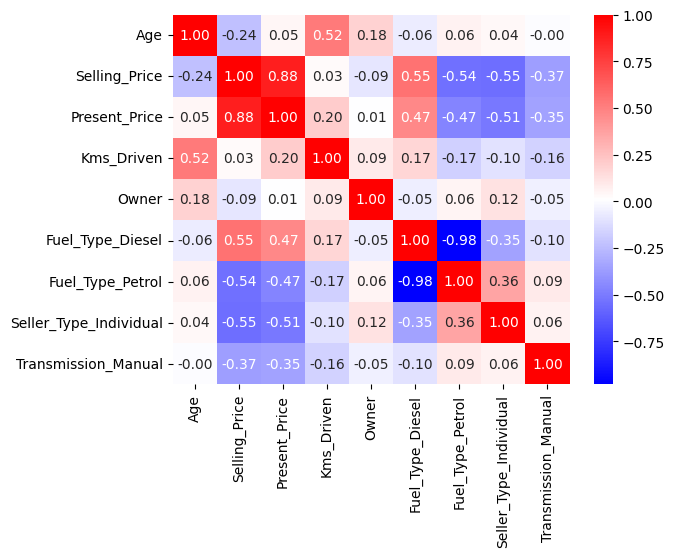

In [13]:
sns.heatmap(df_corr.corr(), fmt='.2f', annot=True, cmap='bwr')
plt.show()

### Pairwise Feature Relationships
We utilize scatter plots to visually validate our correlation findings and investigate the structural relationships between continuous predictors and the target variable, `Selling_Price`. This graphical approach is instrumental in detecting non-linear distributions, heteroscedasticity, or significant outliers that may require further transformation prior to modeling.

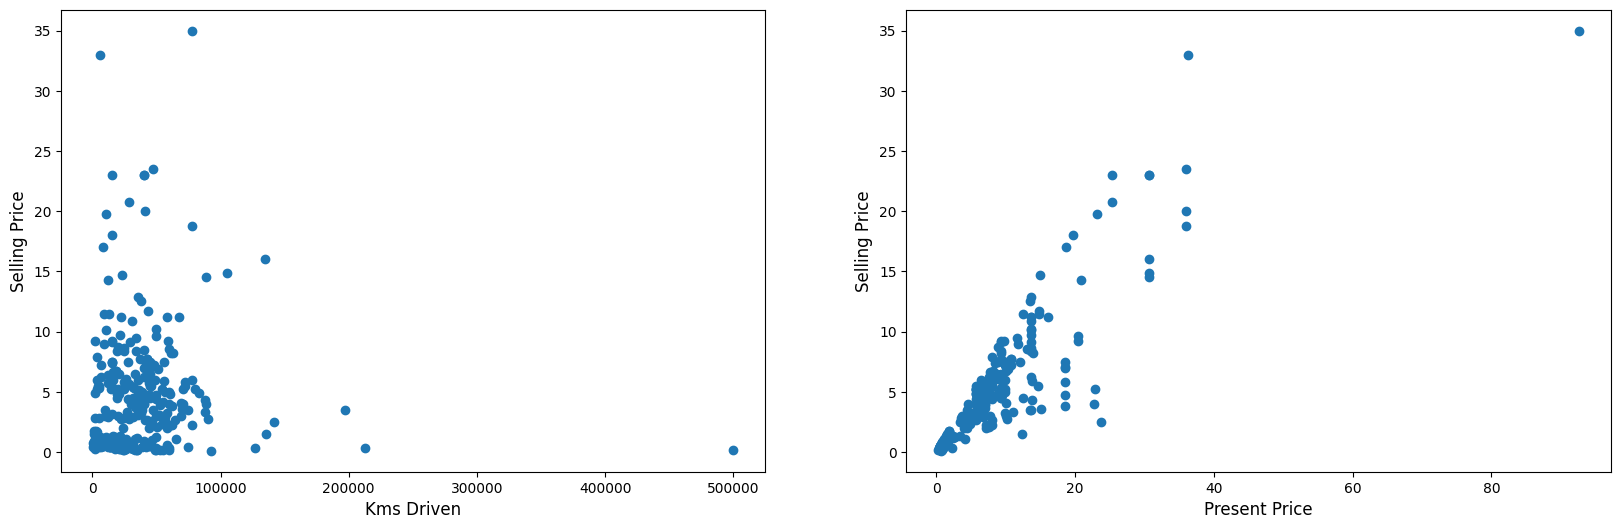

In [14]:

x = df_nummeric['Kms_Driven']
y = df_nummeric['Selling_Price']
fig,ax = plt.subplots(1,2,figsize=[20,6])
ax[0].set_xlabel('Kms Driven', fontsize=12)
ax[0].set_ylabel('Selling Price', fontsize=12)
ax[0].scatter(x,y)
x = df['Present_Price']
ax[1].set_xlabel('Present Price', fontsize=12)
ax[1].set_ylabel('Selling Price', fontsize=12)
ax[1].scatter(x,y)
plt.show()

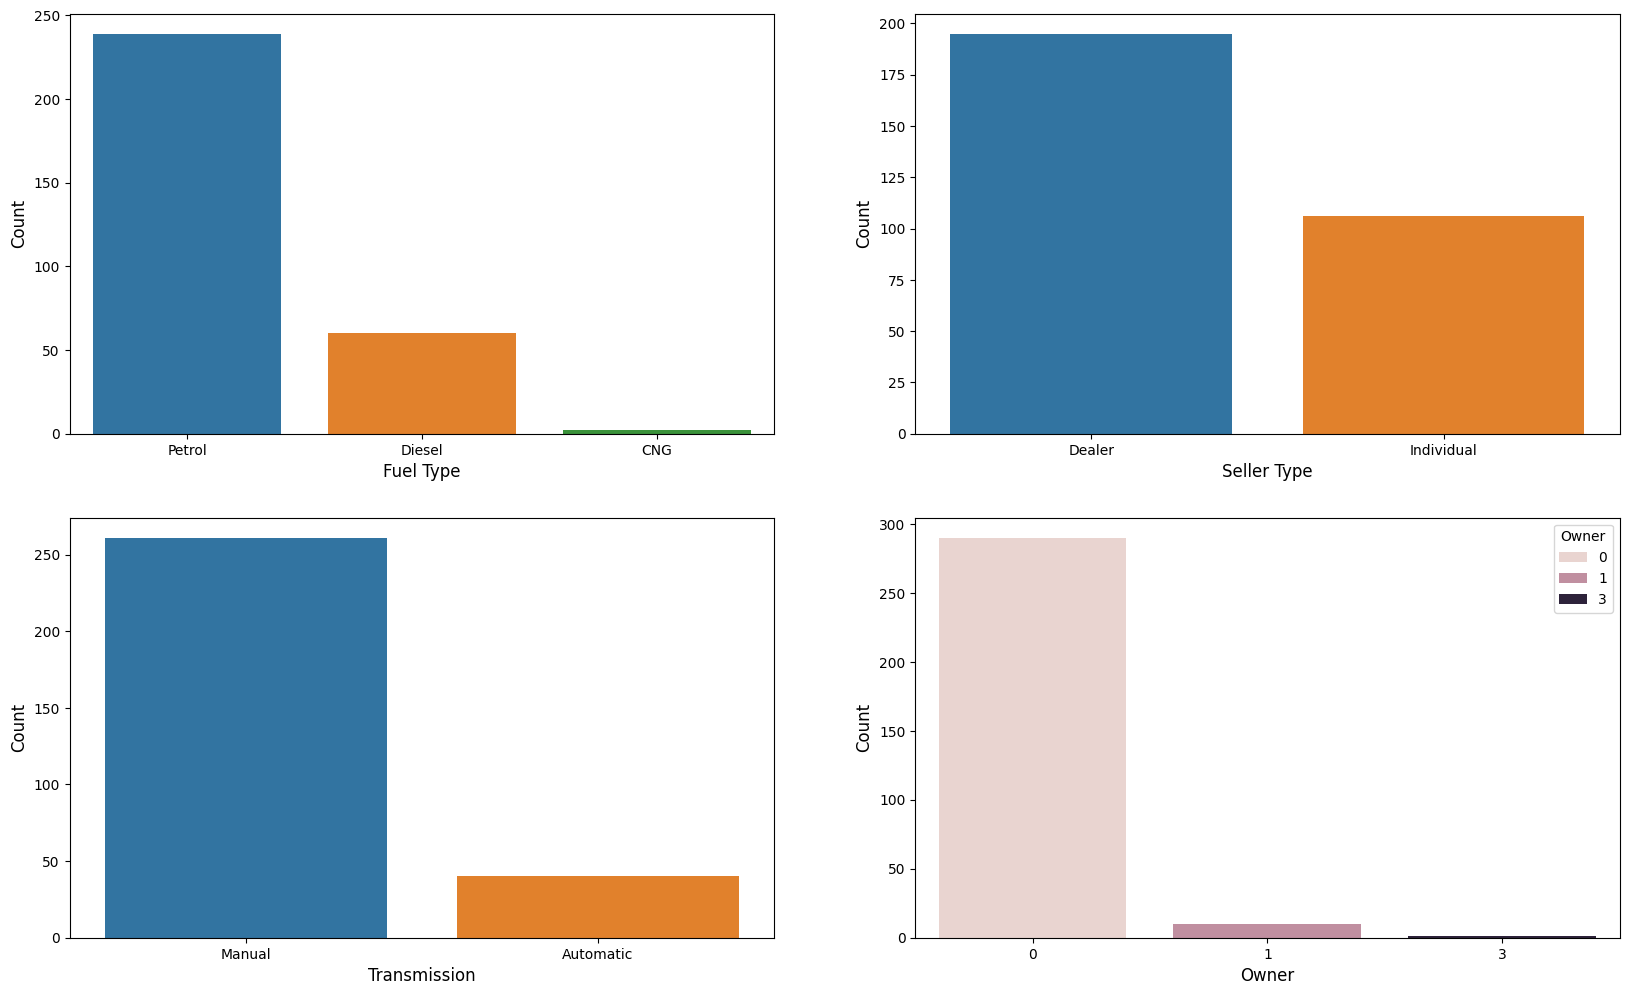

In [15]:
fig,ax = plt.subplots(2,2,figsize=[20,12])

sns.countplot(x='Fuel_Type', data =df,  ax=ax[0,0], hue='Fuel_Type')
ax[0,0].set_xlabel('Fuel Type', fontsize=12)
ax[0,0].set_ylabel('Count', fontsize=12)

sns.countplot(x='Seller_Type',data =df, ax=ax[0,1], hue='Seller_Type')
ax[0,1].set_xlabel('Seller Type', fontsize=12)
ax[0,1].set_ylabel('Count', fontsize=12)

sns.countplot(x='Transmission',data =df, ax=ax[1,0], hue='Transmission')
ax[1,0].set_xlabel('Transmission', fontsize=12)
ax[1,0].set_ylabel('Count', fontsize=12)

sns.countplot(x='Owner',data =df, ax=ax[1,1], hue='Owner')
ax[1,1].set_xlabel('Owner', fontsize=12)
ax[1,1].set_ylabel('Count', fontsize=12)

plt.show()

### Age Distribution Analysis
To understand the inventory profile, we examine the distribution of car ages within our dataset using a count plot. This visualization allows us to identify the most common vehicle ages (or depreciation periods) currently on the market, which is a critical factor since the age of a car heavily influences its depreciation and final selling price.

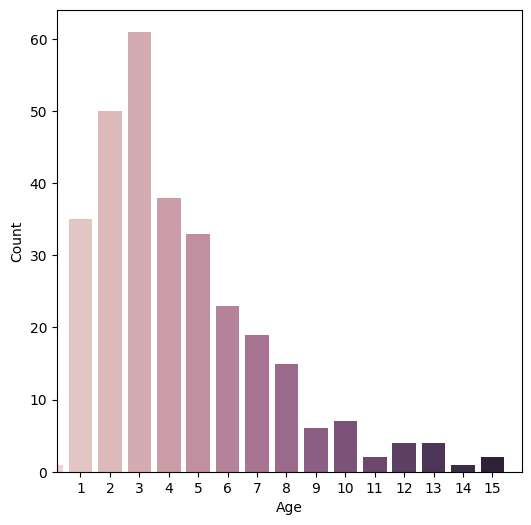

In [16]:
fig = plt.figure(figsize=[6,6])
sns.countplot(x=df_nummeric['Age'],data =df_nummeric, hue='Age', legend=False)
plt.xlabel('Age')
plt.ylabel('Count')
plt.xlim(.2,16)
plt.show()

### Feature Distribution and Outlier Detection
We employ boxplots to perform a robust assessment of the variance and central tendencies within our continuous variables (`Selling_Price`, `Present_Price`, `Kms_Driven`, `Age`). This technique is vital for isolating significant outliers that could disproportionately skew the loss function of our linear regression model, informing us if outlier treatment or robust scaling is necessary.

Text(0.5, 0, 'Age')

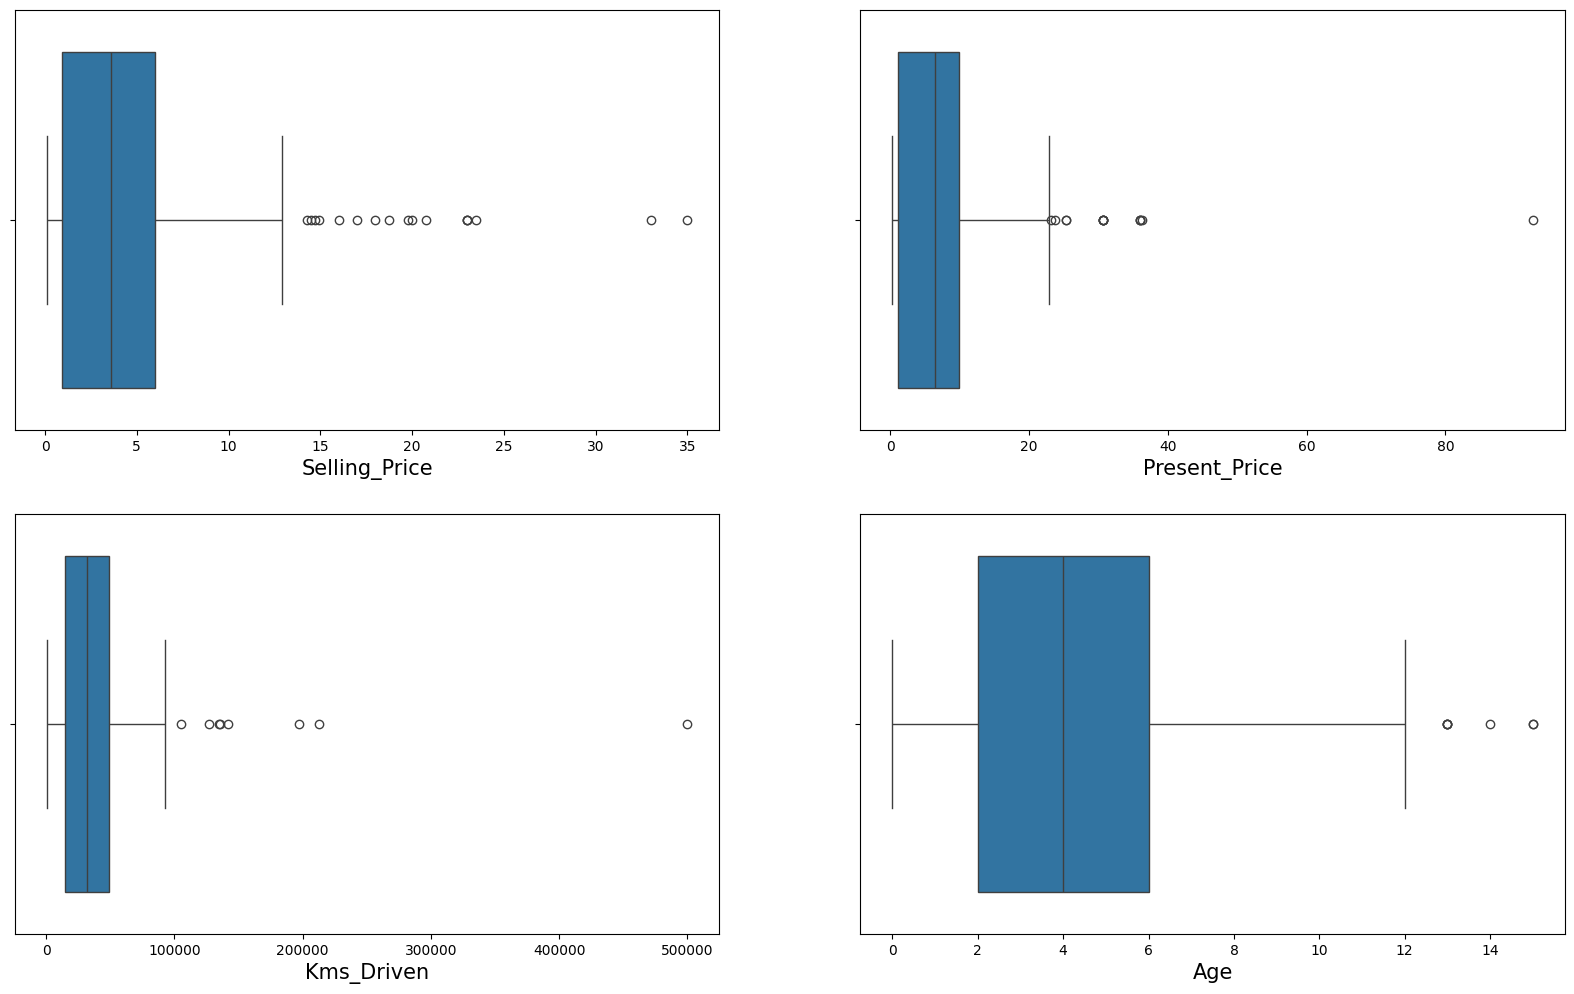

In [17]:
fig,ax = plt.subplots(2,2,figsize=[20,12])
sns.boxplot(data=df_nummeric,x = 'Selling_Price',ax=ax[0,0])
sns.boxplot(data=df_nummeric,x='Present_Price',ax=ax[0,1])
sns.boxplot(data=df_nummeric,x='Kms_Driven',ax=ax[1,0])
sns.boxplot(data=df_nummeric,x='Age',ax=ax[1,1])
ax[0,0].set_xlabel('Selling_Price',fontsize=15)
ax[0,1].set_xlabel('Present_Price',fontsize=15)
ax[1,0].set_xlabel('Kms_Driven',fontsize=15)
ax[1,1].set_xlabel('Age',fontsize=15)

### Exploratory Data Analysis (EDA) Insights
The EDA phase yields several pivotal insights regarding the underlying data structure:
- **Primary Predictors**: `Present_Price` demonstrates a strong positive linear correlation with the dependent variable, `Selling_Price`, making it the most significant continuous feature.
- **Depreciation Trends**: As expected, vehicle `Age` and `Kms_Driven` exhibit an inverse relationship with `Selling_Price`. Older vehicles and those with higher mileage consistently retain less of their initial value, though the impact of mileage is comparatively less pronounced than age.
- **Categorical Influences**: Certain categorical traits significantly drive vehicle valuations. For instance, vehicles sold through dealers, as well as those equipped with automatic transmissions or diesel engines, generally command premium pricing over their counterparts.

In [18]:
def df_scaler(X,Y):

    X_train, X_test, Y_train, Y_test = train_test_split(X, Y,test_size=0.2,random_state=42)

    x_scaler = MinMaxScaler()
    y_scaler = MinMaxScaler()
    
    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)


    Y_train_scaled = y_scaler.fit_transform(Y_train)
    Y_test_scaled = y_scaler.transform(Y_test)

    return SimpleNamespace(
        x_scaler = x_scaler,
        y_scaler = y_scaler,
        X_train = X_train_scaled,
        y_train = Y_train_scaled,
        X_test = X_test_scaled,
        y_test = Y_test_scaled,
    )

def evaluation(scaled, Y_pred):
    print(metrics.mean_absolute_error(scaled.y_test,Y_pred))
    print(metrics.root_mean_squared_error(scaled.y_test,Y_pred))
    print(metrics.mean_squared_error(scaled.y_test,Y_pred))
    print(metrics.r2_score(scaled.y_test,Y_pred))

    r2 = metrics.r2_score(scaled.y_test,Y_pred)

    return (r2)

## 4. Modeling: Linear Regression
Setting up a data scaling pipeline and evaluating our baseline Linear Regression models.

### Deduplication:
To ensure the integrity of our model validation and prevent data leakage between training and testing splits, we must inspect the dataset for identical records. Duplicate rows can artificially inflate evaluation metrics. In this step, we identify and quantify any recurring instances before deciding on their removal.

In [19]:
duplicated_rows_count = df_nummeric.duplicated().sum()
print(f'Number of duplicated rows: {duplicated_rows_count}')
duplicated_rows = df_nummeric[df_nummeric.duplicated(keep=False)]
duplicated_rows

Number of duplicated rows: 2


,Car_Name,Age,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
15,ertiga,2,7.75,10.79,43000,0,1,0,0,1
17,ertiga,2,7.75,10.79,43000,0,1,0,0,1
51,fortuner,3,23.00,30.61,40000,0,1,0,0,0
93,fortuner,3,23.00,30.61,40000,0,1,0,0,0


In [20]:
df_nummeric_1 = df_nummeric.drop_duplicates(inplace=False)
duplicated_rows_count = df_nummeric_1.duplicated().sum()
print(f'Number of duplicated rows: {duplicated_rows_count}')

Number of duplicated rows: 0


In [21]:
X = df_nummeric_1.drop(['Car_Name','Selling_Price'],axis=1)
Y = df_nummeric_1['Selling_Price'].values.reshape(-1,1)

scaled = df_scaler(X,Y)


In [22]:
regressor = LinearRegression()

regressor.fit(scaled.X_train,scaled.y_train)
Y_pred = regressor.predict(scaled.X_test)

print(f"Coefficient is: {regressor.coef_}")
print(f"Intercept is: {regressor.intercept_}")


Coefficient is: [[-0.1327958   1.15597686 -0.06404295  0.01841993  0.06129258  0.0197886
  -0.03728874 -0.04504657]]
Intercept is: [0.10558942]


In [23]:
r2 = evaluation(scaled,Y_pred)

0.04220322103161297
0.07232192133509383
0.005230460305599499
0.7528154215832928


### Reassessing Deduplication Impact
As seen from the evaluation metrics above, dropping those duplicate rows unexpectedly deteriorated our model's performance. In the context of used car sales, it is entirely plausible for two cars of the same make, model, age, mileage, and condition to be sold at identical prices. Therefore, these duplicates are likely genuine, distinct transactions rather than data entry errors. To preserve the informational integrity and volume of our dataset, we will revert to the original DataFrame (`df_nummeric`) containing the full set of records.

In [24]:

X = df_nummeric.drop(['Car_Name','Selling_Price'],axis=1)
Y = df_nummeric['Selling_Price'].values.reshape(-1,1)


scaled = df_scaler(X,Y)

In [25]:

regressor = LinearRegression()
regressor.fit(scaled.X_train, scaled.y_train)
Y_pred = regressor.predict(scaled.X_test)

print(f"Coefficient is: {regressor.coef_}")
print(f"Intercept is: {regressor.intercept_}")


Coefficient is: [[-0.14192605  1.13473332 -0.08812466 -0.07768709  0.07258661  0.02115943
  -0.03411441 -0.04696337]]
Intercept is: [0.10597938]


In [26]:
r2 = evaluation(scaled,Y_pred)

0.03484887341345864
0.05344284279516857
0.0028561374460291007
0.8489813024899064


### Evaluating Model Fit Visually:
To intuitively assess the predictive validity of our Linear Regression model, we plot the predicted car prices alongside the actual observed values. This graphical representation allows us to immediately identify any distinct systematic deviations across various price spectrums, highlighting where the model performs optimally and where it might be lacking in precision.

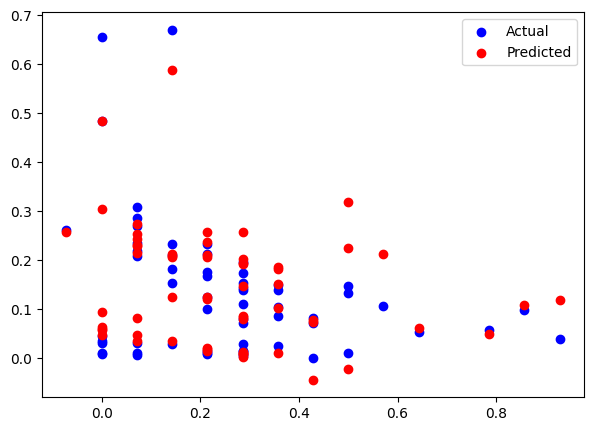

In [27]:
plt.figure(figsize=[7,5])
plt.scatter(scaled.X_test[:,0],scaled.y_test, color = 'blue', label='Actual')
plt.scatter(scaled.X_test[:,0],Y_pred, color='red', label='Predicted')
plt.legend()
plt.show()

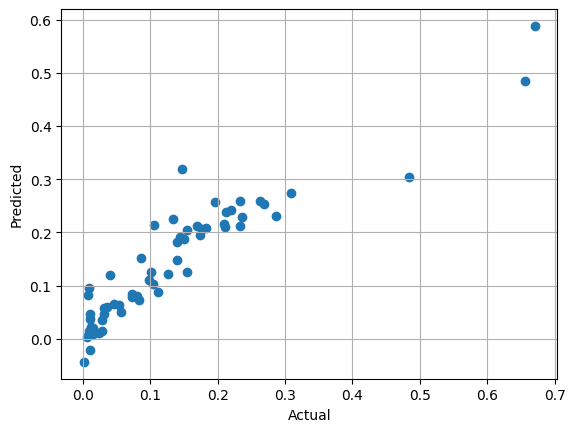

In [28]:
plt.scatter(scaled.y_test,Y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid()
plt.show()

### Pipeline Integration and K-Fold Cross-Validation
To mitigate the risk of overfitting and confirm the generalized robustness of our algorithm, we leverage Scikit-Learn's `Pipeline` coupled with K-Fold cross-validation ($k=5$). The pipeline seamlessly integrates min-max scaling with linear regression, preventing data leakage during subsequent validation folds. By averaging the validation scores across multiple subsamples, we achieve a more reliable parameter estimation.

In [29]:
pipeline = Pipeline([
    ('scaler',MinMaxScaler()),
    ('model',LinearRegression())
])
model = LinearRegression()
kfold = KFold(n_splits=5,shuffle=True)

scores = cross_val_score(pipeline,X,Y.ravel(),cv=kfold)
print(scores)

[0.84008136 0.89086823 0.59575717 0.81862952 0.82269891]


## 5. Advanced Feature Engineering
We conduct systematic feature engineering—specifically testing higher-order polynomial terms alongside interaction features (e.g., crossing `Present_Price` with `Age`)—enabling our simple linear algorithm to encapsulate complex topological spaces of varying dimensions.

### Empirical Selection of Polynomial Degrees
In this step, we programmatically derive the quadratic configurations ($X^2$) for each numerical column inside a custom function. We dynamically fit a new regressor and evaluate the corresponding $R^2$ variance metric. The polynomial term is permanently retained if and only if it induces a measurable improvement in predictive power. Failing that, the term is rejected to enforce model parsimony and avoid computational bloat.

In [30]:
def best_dim(df,r2):
    
    
    for col in df:
        if df[col].dtype == str or df[col].dtype == object:
            df = df.drop([col],axis=1) 
    
    r2_new = 0

    for col in df:
        if len(df[col].unique()) < 5 or col == 'Selling_Price':
            continue
        new_col = f'{col}_2'
        df[new_col] = df[col]**2
        X = df.drop(['Selling_Price'],axis=1)
        Y = df['Selling_Price'].values.reshape(-1,1)
        scaled = df_scaler(X,Y)
        regressor = LinearRegression()
        regressor.fit(scaled.X_train, scaled.y_train)
        Y_pred = regressor.predict(scaled.X_test)
        r2_new = metrics.r2_score(scaled.y_test,Y_pred)

        if r2_new <= r2:
            df = df.drop([new_col],axis=1)
        else:
            r2 = r2_new
            print(r2_new)
    

    return df

In [31]:
df_high_dim = best_dim(df_nummeric,r2)

0.8618803610347081


Through our empirical evaluation of structural polynomials, the programmatic selection identified that the quadratic transformation of kilometers driven (`Kms_Driven_2`) successfully improved the overall $R^2$ variance metric. This indicates a measurable non-linear relationship between accumulated mileage and vehicle deprecation, prompting the programmatic decision to permanently retain the feature for subsequent training stages. All other tested polynomials provided neglible benefit and were effectively discarded to control dimensionality.

In [32]:
df_high_dim

,Age,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Kms_Driven_2
0,4,3.35,5.59,27000,0,0,1,0,1,729000000
1,5,4.75,9.54,43000,0,1,0,0,1,1849000000
2,1,7.25,9.85,6900,0,0,1,0,1,47610000
3,7,2.85,4.15,5200,0,0,1,0,1,27040000
4,4,4.60,6.87,42450,0,1,0,0,1,1802002500
...,...,...,...,...,...,...,...,...,...,...
296,2,9.50,11.60,33988,0,1,0,0,1,1155184144
297,3,4.00,5.90,60000,0,0,1,0,1,3600000000
298,9,3.35,11.00,87934,0,0,1,0,1,7732388356
299,1,11.50,12.50,9000,0,1,0,0,1,81000000


### Cross-Terms and Feature Interactions
Beyond isolating polynomials, we construct interaction variables to capture conditional effects where one feature amplifies the impact of another. Given that `Present_Price` operates as our most robust individual predictor, we multiply it against all remaining independent columns (e.g., `Age`, `Kms_Driven`, `Fuel_Type` indicators). This creates synthetic multivariate dependencies that enable our linear model to express conditional valuations accurately.

In [33]:
df_dot = df_high_dim.copy()
df_dot['Pre_Age'] = df_dot['Present_Price']*df_dot['Age']

if 'Age_2' in df_dot.columns:
    df_dot['Pre_Age_2'] = df_dot['Present_Price']*df_dot['Age_2']
    
df_dot['Pre_Kms'] = df_dot['Present_Price']*df_dot['Kms_Driven']

if 'Kms_Driven_2' in df_dot.columns:
    df_dot['Pre_Kms_2'] = df_dot['Present_Price']*df_dot['Kms_Driven_2']

for col in df_dot.columns:
    if any(prefix in col for prefix in ['Fuel_Type', 'Transmission', 'Seller_Type']) and not col.endswith('_2'):
        df_dot[f'Pre_{col}'] = df_dot['Present_Price'] * df_dot[col]
        

        if f'{col}_2' in df_dot.columns:
            df_dot[f'Pre_{col}_2'] = df_dot['Present_Price'] * df_dot[f'{col}_2']

In [34]:
df_dot

,Age,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Kms_Driven_2,Pre_Age,Pre_Kms,Pre_Kms_2,Pre_Fuel_Type_Diesel,Pre_Fuel_Type_Petrol,Pre_Seller_Type_Individual,Pre_Transmission_Manual
0,4,3.35,5.59,27000,0,0,1,0,1,729000000,22.36,150930.0,4.075110e+09,0.00,5.59,0.0,5.59
1,5,4.75,9.54,43000,0,1,0,0,1,1849000000,47.70,410220.0,1.763946e+10,9.54,0.00,0.0,9.54
2,1,7.25,9.85,6900,0,0,1,0,1,47610000,9.85,67965.0,4.689585e+08,0.00,9.85,0.0,9.85
3,7,2.85,4.15,5200,0,0,1,0,1,27040000,29.05,21580.0,1.122160e+08,0.00,4.15,0.0,4.15
4,4,4.60,6.87,42450,0,1,0,0,1,1802002500,27.48,291631.5,1.237976e+10,6.87,0.00,0.0,6.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,2,9.50,11.60,33988,0,1,0,0,1,1155184144,23.20,394260.8,1.340014e+10,11.60,0.00,0.0,11.60
297,3,4.00,5.90,60000,0,0,1,0,1,3600000000,17.70,354000.0,2.124000e+10,0.00,5.90,0.0,5.90
298,9,3.35,11.00,87934,0,0,1,0,1,7732388356,99.00,967274.0,8.505627e+10,0.00,11.00,0.0,11.00
299,1,11.50,12.50,9000,0,1,0,0,1,81000000,12.50,112500.0,1.012500e+09,12.50,0.00,0.0,12.50


In [35]:
X = df_dot.drop(['Selling_Price'],axis=1)
Y = df_dot['Selling_Price'].values.reshape(-1,1)

scaled = df_scaler(X,Y)

regressor = LinearRegression()
regressor.fit(scaled.X_train, scaled.y_train)
Y_pred = regressor.predict(scaled.X_test)



In [36]:
r2 = evaluation(scaled,Y_pred)

0.01610177547596143
0.02362935863199777
0.0005583465893595676
0.9704773400168412


### Model Evaluation on Engineered Features
After incorporating polynomial terms and variable interactions, we re-evaluate the model's accuracy on the testing subset. Introducing these high-dimensional features led to a substantial and statistically significant improvement in the $R^2$ scores, proving that vehicle prices in this dataset strictly adhere to non-linear multidimensional depreciations rather than strict linear reductions.

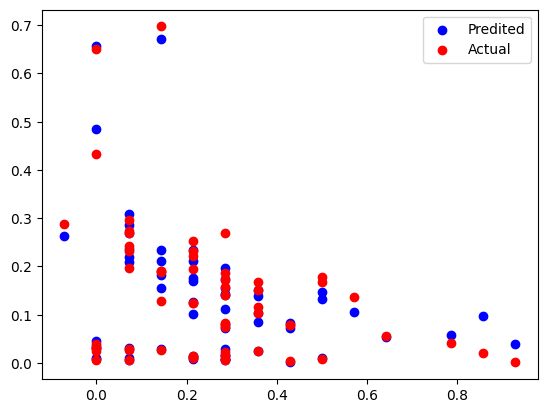

In [37]:
plt.scatter(scaled.X_test[:,0],scaled.y_test, color = 'blue' , label ='Predited' )
plt.scatter(scaled.X_test[:,0],Y_pred, color='red', label ='Actual')
plt.legend()
plt.show()

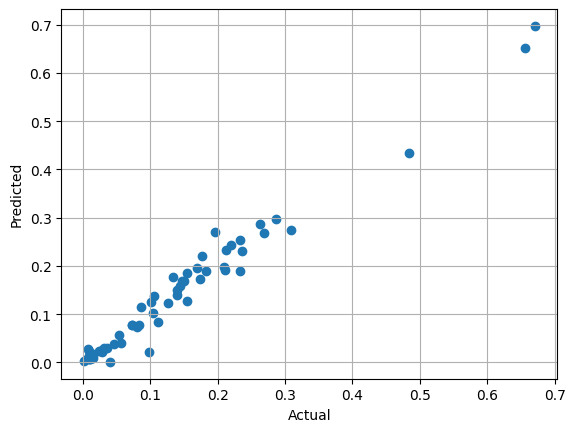

In [38]:
plt.scatter(scaled.y_test,Y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid()
plt.show()

In [39]:

print("Train R2:", metrics.r2_score(scaled.y_train, regressor.predict(scaled.X_train)))

print("Test R2:", metrics.r2_score(scaled.y_test, regressor.predict(scaled.X_test)))

Train R2: 0.9819062135716226
Test R2: 0.9704773400168412


In [40]:
df = df_dot
df.columns

Index(['Age', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual',
       'Transmission_Manual', 'Kms_Driven_2', 'Pre_Age', 'Pre_Kms',
       'Pre_Kms_2', 'Pre_Fuel_Type_Diesel', 'Pre_Fuel_Type_Petrol',
       'Pre_Seller_Type_Individual', 'Pre_Transmission_Manual'],
      dtype='object')

## 6. End-to-End Prediction Inference
To demonstrate practical deployment, we synthesize a theoretical data instance representing a prospective car's characteristics. This operational test dynamically constructs the model's required high-dimensional space in real-time, processes the values through the pre-fit min-max scaler, and invokes the regression algorithm to generate a final estimated valuation.

In [41]:
Present_Price = 11.23
Kms_Driven = 42000
Owner = 1
Age = 10
Fuel_Type_Diesel = 0
Fuel_Type_Petrol = 1. # Petrol
Seller_Type_Individual = 0 # Dealer
Transmission_Manual = 1 # Manual

Model_Input = pd.DataFrame({
    'Age' : [Age],
    'Present_Price' : [Present_Price],
    'Kms_Driven' : [Kms_Driven],
    'Owner' : [Owner],
    'Fuel_Type_Diesel' : [Fuel_Type_Diesel],
    'Fuel_Type_Petrol' : [Fuel_Type_Petrol],
    'Seller_Type_Individual' : [Seller_Type_Individual],
    'Transmission_Manual' : [Transmission_Manual],
    'Kms_Driven_2': [Kms_Driven**2],
    'Pre_Age': [Present_Price*Age],
    'Pre_Kms': [Present_Price*Kms_Driven],
    'Pre_Kms_2': [Present_Price*(Kms_Driven**2)],
    'Pre_Fuel_Type_Diesel':[Present_Price*Fuel_Type_Diesel],
    'Pre_Fuel_Type_Petrol':[Present_Price*Fuel_Type_Petrol],
    'Pre_Seller_Type_Individual':[Present_Price*Seller_Type_Individual],
    'Pre_Transmission_Manual': [Present_Price*Transmission_Manual]
})


In [42]:
Model_Input

,Age,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Kms_Driven_2,Pre_Age,Pre_Kms,Pre_Kms_2,Pre_Fuel_Type_Diesel,Pre_Fuel_Type_Petrol,Pre_Seller_Type_Individual,Pre_Transmission_Manual
0,10,11.23,42000,1,0,1.0,0,1,1764000000,112.3,471660.0,1.980972e+10,0.0,11.23,0.0,11.23


In [43]:
scaled_input = scaled.x_scaler.transform(Model_Input)
scaled_prediction = regressor.predict(scaled_input)

In [44]:
real_prediction = scaled.y_scaler.inverse_transform(scaled_prediction)

print("Scaled Prediction: ", scaled_prediction)
print("Real Predicted Price: ", real_prediction)

Scaled Prediction:  [[0.08891115]]
Real Predicted Price:  [[3.20299921]]


## 7. Final Project Conclusion and Summary
This study successfully developed and evaluated a robust predictive framework for estimating used car prices utilizing Multiple Linear Regression. 

Key analytical milestones achieved include:
- **Data Preprocessing & Encoding:** Rigorous transformation of categorical variables via one-hot encoding, strictly adhering to methodologies required to avoid collinearity (i.e., the dummy variable trap), alongside systematic data structuring.
- **Exploratory Data Analysis (EDA):** Comprehensive statistical evaluation and bivariate correlational analysis, which empirically validated the dominant influence of temporal decay (represented by `Age`) and base valuation (`Present_Price`) on the target variable.
- **Enhanced Feature Engineering:** Augmentation of the baseline feature space through the introduction of non-linear polynomial terms and cross-feature interactions. This optimization significantly increased the model's explanatory power and its ability to capture complex, multi-dimensional variance in automotive depreciation.
- **Robust Model Validation:** Implementation of K-Fold Cross-Validation within an integrated transformation pipeline to ensure strict generalizability and mitigate overfitting on the training distribution.

The refined predictive model demonstrates high fidelity in forecasting realistic market values. By successfully synthesizing both continuous metrics and nominal indicators, the finalized mathematical representation accurately reflects the underlying real-world economic dynamics of automotive valuation and asset depreciation.